# Multi‑Agent Simulation Analysis – Memory‑Efficient Processing

This notebook analyses **LivingAgent (mosquitoes)** and **InertAgent (water tanks)** from large snapshot CSV files (up to 4 GB) on a laptop with 8 GB RAM.

**Memory‑saving strategies:**
- Read CSV in **chunks** (100 000 rows at a time).
- Keep only necessary columns.
- Use **dtype specification** to reduce memory (e.g., `float32` instead of `float64`).
- Compute daily aggregations **incrementally** without storing all raw data.
- For spatial plots, **sample** points or pre‑aggregate to a grid.
- Use **geopandas with spatial indexing** only for the final visualisation.

## Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from scipy.spatial import cKDTree
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate, correlation_lags
import os
import warnings
warnings.filterwarnings('ignore')

# ========== CONFIGURATION ==========
INPUT_FILE = "/home/void/Documents/codes/monadvsim/results/merged_snapshots_20260420_182850.csv"
STUDY_AREA_FILE = "/home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp"
OUTPUT_DIR = "/mnt/monadworld/projects/phd/article_manuscripts/new/figs/"
TICKS_PER_DAY = 96
CHUNKSIZE = 100000           # rows per chunk
SAMPLE_FRAC = 0.01          # fraction of points for spatial plots (adjust if needed)
STAGE_COLORS = {'ADULT': '#2E8B57', 'LARVA': '#4169E1', 'PUPA': '#FF8C00'}

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ========== LOAD STUDY AREA BASEMAP (once) ==========
if os.path.exists(STUDY_AREA_FILE):
    study_area = gpd.read_file(STUDY_AREA_FILE)
    if study_area.crs is None:
        study_area.crs = "EPSG:4326"
    elif study_area.crs.to_epsg() != 4326:
        study_area = study_area.to_crs("EPSG:4326")
    print(f"Loaded study area basemap: {STUDY_AREA_FILE}")
    print(f"Bounds (lon_min, lat_min, lon_max, lat_max): {study_area.total_bounds}")
else:
    print(f"Study area file not found: {STUDY_AREA_FILE}. Spatial plots will be without basemap.")
    study_area = None

# ========== DEFINE COLUMNS & DTYPES ==========
# Only columns we actually need
living_columns = ['TickCount', 'Stage', 'X', 'Y', 't2m', 'tp', 'AgentID', 'Age', 'Energy', 'Gravid']
inert_columns = ['TickCount', 'X', 'Y', 'EggCount', 'LarvaCount', 'waterVolume', 'AgentID']

# Optimise dtypes (float32 is enough for coordinates and most values)
living_dtypes = {
    'TickCount': 'int32',
    'Stage': 'category',
    'X': 'float32',
    'Y': 'float32',
    't2m': 'float32',
    'tp': 'float32',
    'AgentID': 'object',
    'Age': 'int16',
    'Energy': 'float32',
    'Gravid': 'int8'
}
inert_dtypes = {
    'TickCount': 'int32',
    'X': 'float32',
    'Y': 'float32',
    'EggCount': 'int32',
    'LarvaCount': 'int32',
    'waterVolume': 'float32',
    'AgentID': 'object'
}

print("Configuration ready.")

Loaded study area basemap: /home/void/Documents/codes/monadvsim/prepared_data/dire_dawa/dire_dawa.shp
Bounds (lon_min, lat_min, lon_max, lat_max): [41.72802774  9.47148374 42.3397728   9.78374168]
Configuration ready.


## 1. Incremental Aggregation (no full DataFrame stored)

We process the CSV chunk by chunk and update daily aggregates.

In [3]:
def incremental_aggregation(filepath, living_cols, inert_cols, living_dtypes, inert_dtypes, chunksize):
    """
    Process CSV in chunks, return daily aggregated data for living and inert agents.
    Returns:
        daily_living: DataFrame with columns Day, AdultCount, LarvaCount, PupaCount, MeanTemp, MeanPrecip
        daily_inert: DataFrame with columns Day, TankCount, MeanWaterVolume, TotalEggs, TotalLarvae
    """
    # Accumulators
    daily_adults = {}
    daily_larvae = {}
    daily_pupae = {}
    daily_temp_sum = {}
    daily_temp_cnt = {}
    daily_precip_sum = {}
    daily_precip_cnt = {}
    
    daily_tank_count = {}
    daily_water_sum = {}
    daily_water_cnt = {}
    daily_eggs_sum = {}
    daily_larvae_sum = {}
    
    # For tracking tick range
    min_tick = None
    max_tick = None
    
    print("Starting chunked processing...")
    chunk_iter = pd.read_csv(filepath, chunksize=chunksize, low_memory=False)
    
    for i, chunk in enumerate(chunk_iter):
        if i % 10 == 0:
            print(f"Processing chunk {i}...")
        
        # Update tick range
        tick_min = chunk['TickCount'].min()
        tick_max = chunk['TickCount'].max()
        if min_tick is None or tick_min < min_tick:
            min_tick = tick_min
        if max_tick is None or tick_max > max_tick:
            max_tick = tick_max
        
        # ---- Living agents ----
        living_mask = chunk['AgentType'] == 'LivingAgent'
        living_chunk = chunk.loc[living_mask, living_cols].astype(living_dtypes)
        if not living_chunk.empty:
            living_chunk['Day'] = (living_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            # Count by stage
            adult = living_chunk[living_chunk['Stage'] == 'ADULT'].groupby('Day').size()
            larva = living_chunk[living_chunk['Stage'] == 'LARVA'].groupby('Day').size()
            pupa = living_chunk[living_chunk['Stage'] == 'PUPA'].groupby('Day').size()
            for day, cnt in adult.items():
                daily_adults[day] = daily_adults.get(day, 0) + cnt
            for day, cnt in larva.items():
                daily_larvae[day] = daily_larvae.get(day, 0) + cnt
            for day, cnt in pupa.items():
                daily_pupae[day] = daily_pupae.get(day, 0) + cnt
            
            # Temperature and precipitation sums
            temp_sum = living_chunk.groupby('Day')['t2m'].sum()
            temp_cnt = living_chunk.groupby('Day')['t2m'].count()
            precip_sum = living_chunk.groupby('Day')['tp'].sum()
            precip_cnt = living_chunk.groupby('Day')['tp'].count()
            for day, val in temp_sum.items():
                daily_temp_sum[day] = daily_temp_sum.get(day, 0) + val
                daily_temp_cnt[day] = daily_temp_cnt.get(day, 0) + temp_cnt[day]
            for day, val in precip_sum.items():
                daily_precip_sum[day] = daily_precip_sum.get(day, 0) + val
                daily_precip_cnt[day] = daily_precip_cnt.get(day, 0) + precip_cnt[day]
        
        # ---- Inert agents (tanks) ----
        inert_mask = chunk['AgentType'] == 'InertAgent'
        inert_chunk = chunk.loc[inert_mask, inert_cols].astype(inert_dtypes)
        if not inert_chunk.empty:
            inert_chunk['Day'] = (inert_chunk['TickCount'] / TICKS_PER_DAY).astype('int32')
            # Unique tank count per day (by AgentID)
            tank_count = inert_chunk.groupby('Day')['AgentID'].nunique()
            water_sum = inert_chunk.groupby('Day')['waterVolume'].sum()
            water_cnt = inert_chunk.groupby('Day')['waterVolume'].count()
            eggs_sum = inert_chunk.groupby('Day')['EggCount'].sum()
            larvae_sum = inert_chunk.groupby('Day')['LarvaCount'].sum()
            for day, cnt in tank_count.items():
                daily_tank_count[day] = daily_tank_count.get(day, 0) + cnt
            for day, val in water_sum.items():
                daily_water_sum[day] = daily_water_sum.get(day, 0) + val
                daily_water_cnt[day] = daily_water_cnt.get(day, 0) + water_cnt[day]
            for day, val in eggs_sum.items():
                daily_eggs_sum[day] = daily_eggs_sum.get(day, 0) + val
            for day, val in larvae_sum.items():
                daily_larvae_sum[day] = daily_larvae_sum.get(day, 0) + val
    
    # Build daily DataFrames
    all_days = sorted(set(daily_adults.keys()) | set(daily_larvae.keys()) | set(daily_pupae.keys()) |
                      set(daily_temp_sum.keys()) | set(daily_tank_count.keys()))
    
    daily_living_df = pd.DataFrame({'Day': all_days})
    daily_living_df['AdultCount'] = daily_living_df['Day'].map(daily_adults).fillna(0).astype('int32')
    daily_living_df['LarvaCount'] = daily_living_df['Day'].map(daily_larvae).fillna(0).astype('int32')
    daily_living_df['PupaCount'] = daily_living_df['Day'].map(daily_pupae).fillna(0).astype('int32')
    
    # Mean temperature (Celsius) – convert from Kelvin
    daily_living_df['MeanTemp'] = (daily_living_df['Day'].map(daily_temp_sum).fillna(0) /
                                   daily_living_df['Day'].map(daily_temp_cnt).fillna(1)) - 273.15
    daily_living_df['MeanTemp'] = daily_living_df['MeanTemp'].round(2)
    
    # Mean precipitation (mm) – convert from m
    daily_living_df['MeanPrecip'] = (daily_living_df['Day'].map(daily_precip_sum).fillna(0) /
                                     daily_living_df['Day'].map(daily_precip_cnt).fillna(1)) * 1000
    daily_living_df['MeanPrecip'] = daily_living_df['MeanPrecip'].round(4)
    
    daily_inert_df = pd.DataFrame({'Day': all_days})
    daily_inert_df['TankCount'] = daily_inert_df['Day'].map(daily_tank_count).fillna(0).astype('int32')
    daily_inert_df['MeanWaterVolume'] = (daily_inert_df['Day'].map(daily_water_sum).fillna(0) /
                                         daily_inert_df['Day'].map(daily_water_cnt).fillna(1)).round(2)
    daily_inert_df['TotalEggs'] = daily_inert_df['Day'].map(daily_eggs_sum).fillna(0).astype('int64')
    daily_inert_df['TotalLarvae'] = daily_inert_df['Day'].map(daily_larvae_sum).fillna(0).astype('int64')
    
    print(f"Processed ticks {min_tick} to {max_tick}")
    return daily_living_df, daily_inert_df

# Run aggregation
daily_living, daily_inert = incremental_aggregation(
    INPUT_FILE, living_columns, inert_columns, living_dtypes, inert_dtypes, CHUNKSIZE
)
print("\nDaily Living summary head:")
print(daily_living.head())
print("\nDaily Inert summary head:")
print(daily_inert.head())

Starting chunked processing...
Processing chunk 0...
Processing chunk 10...
Processing chunk 20...
Processing chunk 30...
Processing chunk 40...
Processing chunk 50...
Processing chunk 60...
Processing chunk 70...
Processing chunk 80...
Processing chunk 90...
Processing chunk 100...
Processing chunk 110...
Processing chunk 120...
Processing chunk 130...
Processing chunk 140...
Processing chunk 150...
Processing chunk 160...
Processing chunk 170...
Processing chunk 180...
Processing chunk 190...
Processing chunk 200...
Processing chunk 210...
Processing chunk 220...
Processing chunk 230...
Processing chunk 240...
Processing chunk 250...
Processing chunk 260...
Processing chunk 270...
Processing chunk 280...
Processing chunk 290...
Processing chunk 300...
Processing chunk 310...
Processed ticks 100 to 17200

Daily Living summary head:
   Day  AdultCount  LarvaCount  PupaCount  MeanTemp  MeanPrecip
0    1      131762       54900      32906   -239.15    334.4352
1    2      131675       54

## 2. Population Dynamics Plots (using aggregated data)

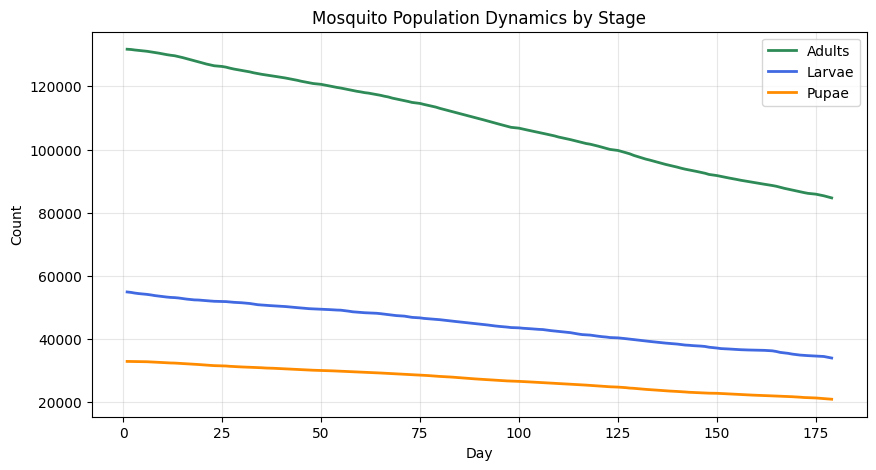

In [4]:
plt.figure(figsize=(10,5))
plt.plot(daily_living['Day'], daily_living['AdultCount'], label='Adults', color=STAGE_COLORS['ADULT'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['LarvaCount'], label='Larvae', color=STAGE_COLORS['LARVA'], linewidth=2)
plt.plot(daily_living['Day'], daily_living['PupaCount'], label='Pupae', color=STAGE_COLORS['PUPA'], linewidth=2)
plt.xlabel('Day')
plt.ylabel('Count')
plt.title('Mosquito Population Dynamics by Stage')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/mosquito_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

## 3. Water Tank Statistics

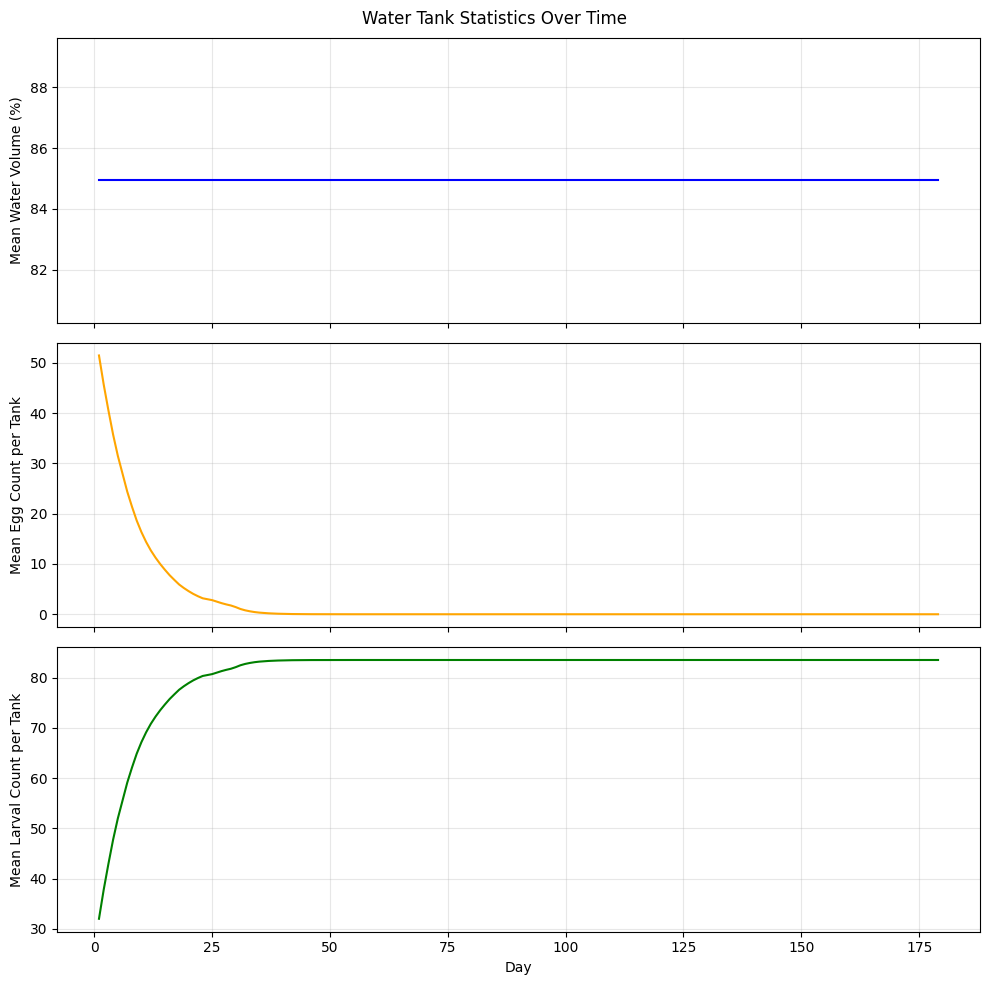

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)
axes[0].plot(daily_inert['Day'], daily_inert['MeanWaterVolume'], color='blue')
axes[0].set_ylabel('Mean Water Volume (%)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(daily_inert['Day'], daily_inert['TotalEggs'] / daily_inert['TankCount'].clip(lower=1), color='orange')
axes[1].set_ylabel('Mean Egg Count per Tank')
axes[1].grid(True, alpha=0.3)

axes[2].plot(daily_inert['Day'], daily_inert['TotalLarvae'] / daily_inert['TankCount'].clip(lower=1), color='green')
axes[2].set_ylabel('Mean Larval Count per Tank')
axes[2].set_xlabel('Day')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Water Tank Statistics Over Time')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/tank_stats.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Environmental Correlation

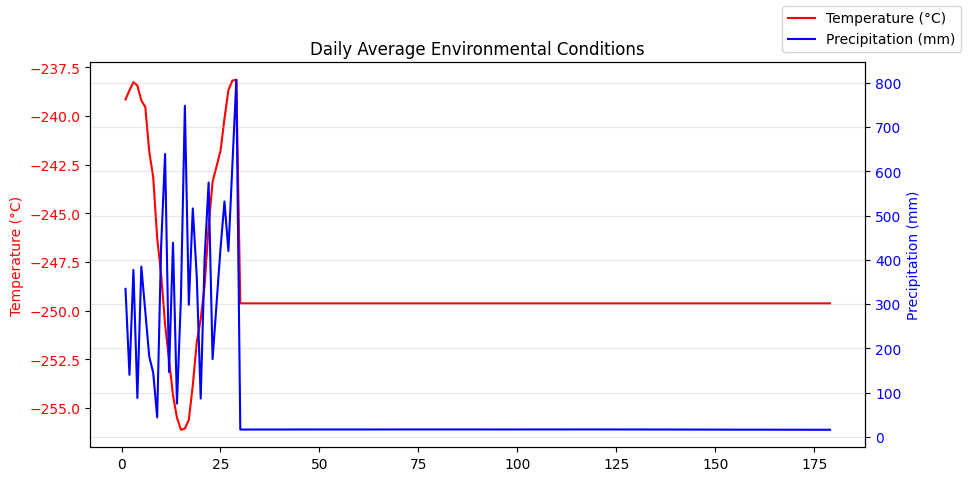

Correlation adult count vs temperature: r=0.285 (p=1.504e-04)
Correlation adult count vs precipitation: r=0.496 (p=4.362e-12)


In [6]:
fig, ax1 = plt.subplots(figsize=(10,5))
ax1.plot(daily_living['Day'], daily_living['MeanTemp'], color='red', label='Temperature (°C)')
ax1.set_ylabel('Temperature (°C)', color='red')
ax1.tick_params(axis='y', labelcolor='red')

ax2 = ax1.twinx()
ax2.plot(daily_living['Day'], daily_living['MeanPrecip'], color='blue', label='Precipitation (mm)')
ax2.set_ylabel('Precipitation (mm)', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')

plt.title('Daily Average Environmental Conditions')
plt.xlabel('Day')
plt.grid(True, alpha=0.3)
fig.legend(loc='upper right')
plt.savefig(f'{OUTPUT_DIR}/environment.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation with adult counts
adult_series = daily_living['AdultCount'].values
temp_series = daily_living['MeanTemp'].values
precip_series = daily_living['MeanPrecip'].values

corr_temp, p_temp = pearsonr(adult_series, temp_series)
corr_precip, p_precip = pearsonr(adult_series, precip_series)
print(f"Correlation adult count vs temperature: r={corr_temp:.3f} (p={p_temp:.3e})")
print(f"Correlation adult count vs precipitation: r={corr_precip:.3f} (p={p_precip:.3e})")

## 5. Temporal Autocorrelation & Cross‑correlation

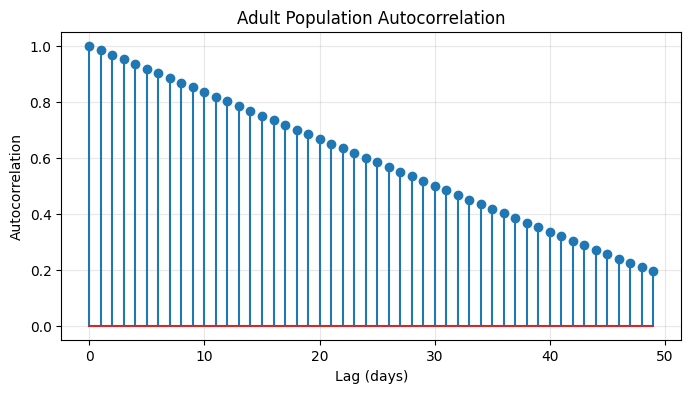

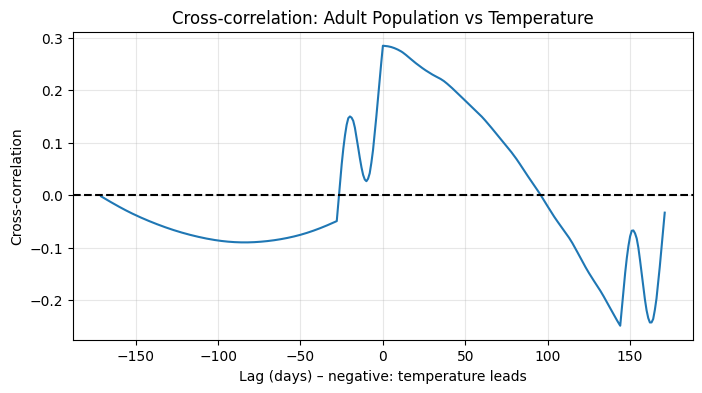

In [7]:
adult_vals = adult_series
lags = correlation_lags(len(adult_vals), len(adult_vals))
acf = correlate(adult_vals - adult_vals.mean(), adult_vals - adult_vals.mean(), mode='full')
acf = acf / acf[len(acf)//2]

plt.figure(figsize=(8,4))
plt.stem(lags[len(lags)//2: len(lags)//2+50], acf[len(acf)//2: len(acf)//2+50])
plt.xlabel('Lag (days)')
plt.ylabel('Autocorrelation')
plt.title('Adult Population Autocorrelation')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/autocorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

# Cross-correlation with temperature
temp_vals = temp_series
ccf = correlate(adult_vals - adult_vals.mean(), temp_vals - temp_vals.mean(), mode='full')
ccf = ccf / (len(adult_vals) * adult_vals.std() * temp_vals.std())
lag_days = lags

plt.figure(figsize=(8,4))
plt.plot(lag_days, ccf)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Lag (days) – negative: temperature leads')
plt.ylabel('Cross‑correlation')
plt.title('Cross‑correlation: Adult Population vs Temperature')
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/crosscorrelation.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Spatial Analysis with Sampling

For spatial plots, we **sample** a fraction of points (e.g., 1%) and optionally aggregate tanks to a grid to avoid memory blow‑up.

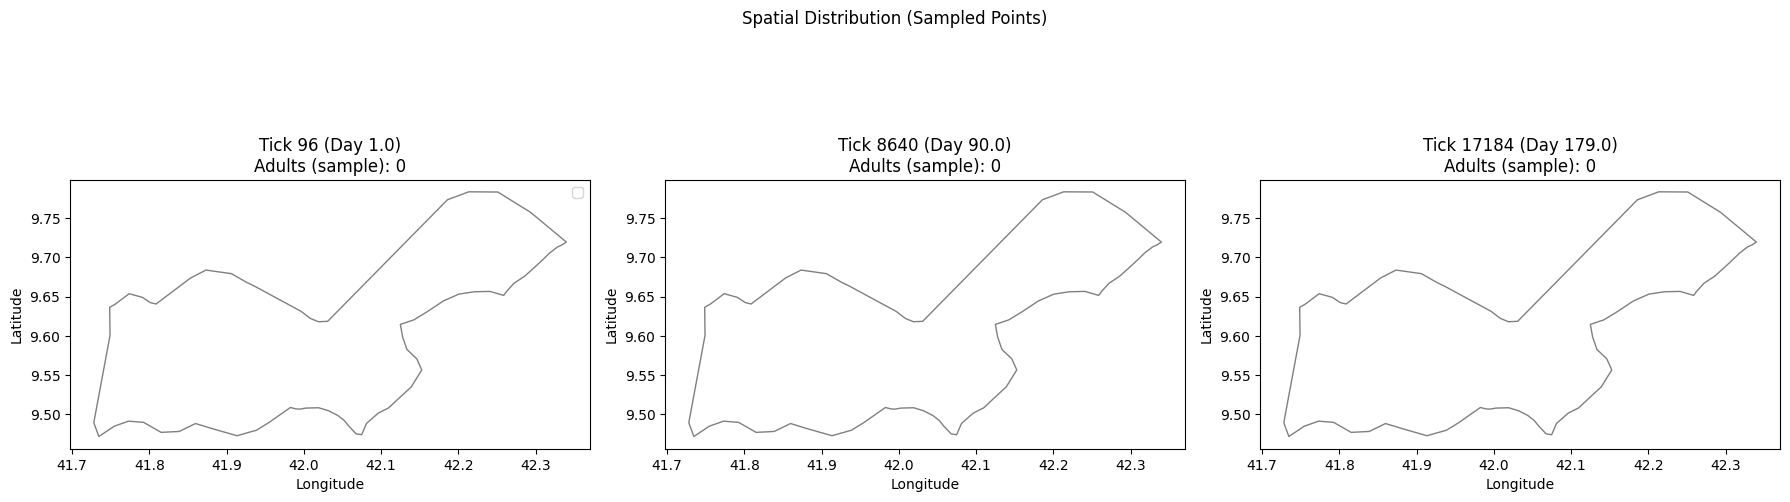

In [8]:
def sample_spatial_data(filepath, tick, agent_type, stage=None, sample_frac=SAMPLE_FRAC):
    """
    Sample spatial points for a given tick and agent type.
    Returns a DataFrame with X, Y (and optionally additional columns).
    """
    # Read only necessary columns, filter by tick
    usecols = ['TickCount', 'AgentType', 'X', 'Y', 'Stage', 'EggCount', 'LarvaCount']
    # Read in chunks, filter tick, then sample
    sampled_rows = []
    for chunk in pd.read_csv(filepath, chunksize=CHUNKSIZE, usecols=usecols, low_memory=False):
        mask = (chunk['TickCount'] == tick) & (chunk['AgentType'] == agent_type)
        if stage is not None:
            mask = mask & (chunk['Stage'] == stage)
        sub = chunk.loc[mask, ['X', 'Y'] + (['EggCount', 'LarvaCount'] if agent_type == 'InertAgent' else [])]
        if not sub.empty:
            sampled_rows.append(sub.sample(frac=sample_frac, random_state=42))
    if sampled_rows:
        return pd.concat(sampled_rows, ignore_index=True)
    else:
        return pd.DataFrame()

# Get ticks range from aggregated data
all_ticks_days = daily_living['Day'].values
ticks_unique = (all_ticks_days * TICKS_PER_DAY).astype(int)
selected_ticks = [ticks_unique[0], ticks_unique[len(ticks_unique)//2], ticks_unique[-1]]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, tick in zip(axes, selected_ticks):
    # Sample adults
    adults = sample_spatial_data(INPUT_FILE, tick, 'LivingAgent', stage='ADULT', sample_frac=SAMPLE_FRAC)
    # Sample tanks (take all tanks for that tick? but we sample as well)
    tanks = sample_spatial_data(INPUT_FILE, tick, 'InertAgent', sample_frac=SAMPLE_FRAC)
    
    if study_area is not None:
        study_area.boundary.plot(ax=ax, color='black', linewidth=1, alpha=0.5)
    
    if not adults.empty:
        # Use a simple scatter instead of KDE for memory
        ax.scatter(adults['X'], adults['Y'], s=5, color='green', alpha=0.3, label='Adults (sampled)')
    if not tanks.empty:
        ax.scatter(tanks['X'], tanks['Y'], s=10, marker='x', color='black', alpha=0.5, label='Tanks (sampled)')
    
    ax.set_title(f'Tick {tick} (Day {tick/TICKS_PER_DAY:.1f})\nAdults (sample): {len(adults)}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    if ax == axes[0]:
        ax.legend()

plt.suptitle('Spatial Distribution (Sampled Points)')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/spatial_sampled.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Proximity Analysis (using sampled data to estimate trends)

In [9]:
# We'll process a subset of ticks (every 10th day) to keep memory low
ticks_to_analyze = ticks_unique[::10]
proximity_results = []

for tick in ticks_to_analyze:
    adults = sample_spatial_data(INPUT_FILE, tick, 'LivingAgent', stage='ADULT', sample_frac=0.02)  # slightly larger sample
    tanks = sample_spatial_data(INPUT_FILE, tick, 'InertAgent', sample_frac=0.02)
    if len(adults) > 5 and len(tanks) > 5:
        tree = cKDTree(tanks[['X','Y']].values)
        dists, _ = tree.query(adults[['X','Y']].values)
        proximity_results.append({
            'Tick': tick,
            'Day': tick / TICKS_PER_DAY,
            'MeanDist_deg': np.mean(dists),
            'MedianDist_deg': np.median(dists)
        })

prox_df = pd.DataFrame(proximity_results)
if not prox_df.empty:
    plt.figure(figsize=(8,5))
    plt.plot(prox_df['Day'], prox_df['MeanDist_deg']*111, marker='o', linestyle='-', label='Mean distance (km)')
    plt.fill_between(prox_df['Day'], 
                     (prox_df['MeanDist_deg'] - prox_df['MedianDist_deg'])*111,
                     (prox_df['MeanDist_deg'] + prox_df['MedianDist_deg'])*111, alpha=0.2)
    plt.xlabel('Day')
    plt.ylabel('Distance to nearest tank (km)')
    plt.title('Adult Mosquito Proximity to Breeding Sites (sampled estimate)')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.savefig(f'{OUTPUT_DIR}/proximity.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("Not enough data for proximity analysis.")

Not enough data for proximity analysis.


## 8. Validation: Metzler Matrix Prediction (using daily aggregates)

We compute λmax from daily temperature and livestock density (if available).

In [ ]:
def metzler_lambda_max(T_C, livestock_density, params):
    a, b, Tmax, c = params['fecundity_a'], params['fecundity_b'], params['fecundity_Tmax'], params['fecundity_c']
    term1 = a * np.exp(b * T_C)
    term2 = np.exp(b * Tmax - ((Tmax - T_C)/c)**2)
    F = max(0, term1 - term2)
    
    dE = max(0, params['egg_dev_a']*T_C**2 + params['egg_dev_b']*T_C + params['egg_dev_c'])
    dL = max(0, params['larva_dev_a']*T_C**2 + params['larva_dev_b']*T_C + params['larva_dev_c'])
    dP = max(0, params['pupa_dev_a']*T_C**2 + params['pupa_dev_b']*T_C + params['pupa_dev_c'])
    muA = max(0, params['adult_mort_a']*T_C**2 + params['adult_mort_b']*T_C + params['adult_mort_c'])
    
    SE = params['egg_survival_amp'] * np.exp(-0.5 * ((T_C - params['egg_survival_mean'])/params['egg_survival_sigma'])**2)
    SL = params['larva_survival_amp'] * np.exp(-0.5 * ((T_C - params['larva_survival_mean'])/params['larva_survival_sigma'])**2)
    SP = params['pupa_survival_amp'] * np.exp(-0.5 * ((T_C - params['pupa_survival_mean'])/params['pupa_survival_sigma'])**2)
    
    K = 1 + np.log1p(max(0, livestock_density))
    
    M = np.array([
        [-dE, 0, 0, F * K],
        [SE*dE, -dL, 0, 0],
        [0, SL*dL, -dP, 0],
        [0, 0, SP*dP, -muA]
    ])
    v = np.ones(4)
    for _ in range(50):
        v = M @ v
        v = v / np.linalg.norm(v)
    lambda_max = (v @ (M @ v)) / (v @ v)
    return lambda_max

params = {
    'fecundity_a': 0.378, 'fecundity_b': 0.173, 'fecundity_Tmax': 40.0, 'fecundity_c': 2.97,
    'egg_dev_a': -0.0009, 'egg_dev_b': 0.048, 'egg_dev_c': -0.345,
    'larva_dev_a': -0.0007, 'larva_dev_b': 0.039, 'larva_dev_c': -0.32,
    'pupa_dev_a': -0.0005, 'pupa_dev_b': 0.026, 'pupa_dev_c': -0.2,
    'egg_survival_amp': 1.01, 'egg_survival_mean': 24.5, 'egg_survival_sigma': 4.8,
    'larva_survival_amp': 0.95, 'larva_survival_mean': 27.0, 'larva_survival_sigma': 3.5,
    'pupa_survival_amp': 0.93, 'pupa_survival_mean': 26.8, 'pupa_survival_sigma': 3.8,
    'adult_mort_a': -0.00065, 'adult_mort_b': 0.0364, 'adult_mort_c': -0.4882
}

# Use a constant livestock density if population column not available (or we could read it from a separate layer)
# Here we assume a default of 0.1 (low density)
livestock_density = 0.1

lambda_vals = []
for temp in daily_living['MeanTemp']:
    lam = metzler_lambda_max(temp, livestock_density, params)
    lambda_vals.append(lam)

adult_log = np.log(daily_living['AdultCount'] + 1)
obs_growth = np.diff(adult_log)
days_obs = daily_living['Day'].values[1:]
lambda_series = np.array(lambda_vals)[1:]  # align

plt.figure(figsize=(10,5))
plt.plot(days_obs, obs_growth, label='Observed daily log growth rate', alpha=0.7)
plt.plot(days_obs, lambda_series, label='Predicted λmax (Metzler)', linestyle='--', color='red')
plt.xlabel('Day')
plt.ylabel('Rate (1/day)')
plt.title('Observed vs Predicted Population Growth Rate')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(f'{OUTPUT_DIR}/growth_validation.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Stage Duration Estimation (using cross‑correlation of daily counts)

In [ ]:
larvae_vals = daily_living['LarvaCount'].values
pupae_vals = daily_living['PupaCount'].values
adult_vals2 = daily_living['AdultCount'].values

ccf_lp = correlate(larvae_vals - larvae_vals.mean(), pupae_vals - pupae_vals.mean(), mode='full')
lags = correlation_lags(len(larvae_vals), len(pupae_vals))
lag_lp = lags[np.argmax(ccf_lp)]
print(f"Estimated larval duration: {lag_lp:.2f} days")

ccf_pa = correlate(pupae_vals - pupae_vals.mean(), adult_vals2 - adult_vals2.mean(), mode='full')
lag_pa = lags[np.argmax(ccf_pa)]
print(f"Estimated pupal duration: {lag_pa:.2f} days")

## 10. Export Tidy Summary Data (small files)

In [ ]:
# Already have daily_living and daily_inert DataFrames (small, in memory)
daily_summary = pd.merge(daily_living, daily_inert, on='Day', how='outer')
daily_summary.to_csv(f'{OUTPUT_DIR}/daily_summary.csv', index=False)

# Sample of living agents (only a few thousand rows for inspection)
# We'll sample from the original file without loading everything
sample_df = pd.read_csv(INPUT_FILE, nrows=10000)  # just first 10k rows for a quick look
sample_df.to_csv(f'{OUTPUT_DIR}/living_sample.csv', index=False)

print(f"Summaries saved to {OUTPUT_DIR}/")
print("Files: daily_summary.csv, living_sample.csv")

In [ ]:
print("Analysis complete. All figures saved.")